# Regularization loss landscapes

Comparing four regularization strategies in correlation-magnitude space:
1. **Standard L2** (no embedding): $\|W\|^2 / n$
2. **L2 with embedding**: $\sum W^2 \cdot \text{kernel}$
3. **Correlation only**: $1 - r(W, S)$
4. **Combined correlation + L2**: $(1 - r) + \|W\|^2 / n$

Axes: Pearson $r(W, S)$ vs $\|W\|$ (Frobenius norm). This shows what each loss function rewards and penalizes in terms of the quantities we care about.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LightSource
from scipy.interpolate import griddata

np.random.seed(42)

# --- Toy setup ---
n = 10
kernel = np.random.rand(n, n)
kernel = (kernel + kernel.T) / 2
np.fill_diagonal(kernel, 0)
kernel = kernel / kernel.max()

similarity = 1.0 - kernel
off_diag = ~np.eye(n, dtype=bool)

s_flat = similarity[off_diag]
s_flat_centered = s_flat - s_flat.mean()
s_flat_std = np.sqrt((s_flat_centered ** 2).sum())

# Orthogonal random direction (same scale as S)
r_flat = np.random.randn(len(s_flat))
r_flat = r_flat - (r_flat @ s_flat_centered) / (s_flat_centered @ s_flat_centered) * s_flat_centered
r_flat = r_flat / np.linalg.norm(r_flat) * np.linalg.norm(s_flat)

def flat_to_matrix(flat_vals):
    M = np.zeros((n, n))
    M[off_diag] = flat_vals
    return M

S_mat = flat_to_matrix(s_flat)
R_mat = flat_to_matrix(r_flat)

# --- Loss functions ---
def compute_corr(W):
    w_flat = W[off_diag]
    w_c = w_flat - w_flat.mean()
    w_std = np.sqrt((w_c ** 2).sum())
    if w_std < 0.01:
        return np.nan  # undefined at near-zero magnitude
    return (w_c @ s_flat_centered) / (w_std * s_flat_std)

def loss_l2_standard(W):
    """Standard L2: ||W||^2 / n"""
    return np.sum(W**2) / n

def loss_l2_kernel(W):
    """L2 with embedding kernel: sum(W^2 * kernel)"""
    return np.sum(W**2 * kernel)

def loss_corr_only(W):
    """Correlation only: 1 - r"""
    r = compute_corr(W)
    if np.isnan(r):
        return np.nan
    return 1.0 - r

def loss_combined(W):
    """Combined: (1 - r) + ||W||^2 / n"""
    r = compute_corr(W)
    if np.isnan(r):
        return np.nan
    return (1.0 - r) + np.sum(W**2) / n

In [8]:
# --- Compute losses over (α, β) grid ---
alphas = np.linspace(-1.5, 1.5, 300)
betas = np.linspace(-1.5, 1.5, 300)
A, B = np.meshgrid(alphas, betas)

loss_fns = {
    'Standard L2': loss_l2_standard,
    'L2 with kernel': loss_l2_kernel,
    'Correlation only': loss_corr_only,
    'Correlation + L2': loss_combined,
}

Z = {name: np.zeros_like(A) for name in loss_fns}
R_corr = np.zeros_like(A)
W_mag = np.zeros_like(A)

for i in range(len(betas)):
    for j in range(len(alphas)):
        W = A[i, j] * S_mat + B[i, j] * R_mat
        R_corr[i, j] = compute_corr(W)
        W_mag[i, j] = np.linalg.norm(W)  # Frobenius norm
        for name, fn in loss_fns.items():
            Z[name][i, j] = fn(W)

# --- Remap to (correlation, magnitude) grid ---
# Limit magnitude to well-sampled region to avoid interpolation artifacts at edges
mag_max = np.percentile(W_mag, 75)
corr_grid = np.linspace(-1, 1, 300)
mag_grid = np.linspace(0, mag_max, 300)
CG, MG = np.meshgrid(corr_grid, mag_grid)

r_flat_grid = R_corr.flatten()
m_flat_grid = W_mag.flatten()

Z_rm = {}
for name in loss_fns:
    Z_rm[name] = griddata((r_flat_grid, m_flat_grid), Z[name].flatten(),
                          (CG, MG), method='linear')

# Build a validity mask: True where we have enough sampled data nearby.
# Use 'nearest' interpolation distance — if nearest sample is too far, mark as invalid.
from scipy.spatial import cKDTree
tree = cKDTree(np.column_stack([r_flat_grid, m_flat_grid / mag_max]))  # normalize scales
grid_pts = np.column_stack([CG.flatten(), MG.flatten() / mag_max])
dists, _ = tree.query(grid_pts)
valid_mask = (dists < 0.05).reshape(CG.shape)  # threshold for "well-sampled"

for name in Z_rm:
    Z_rm[name] = np.where(valid_mask, Z_rm[name], np.nan)

## Contour plots in correlation-magnitude space

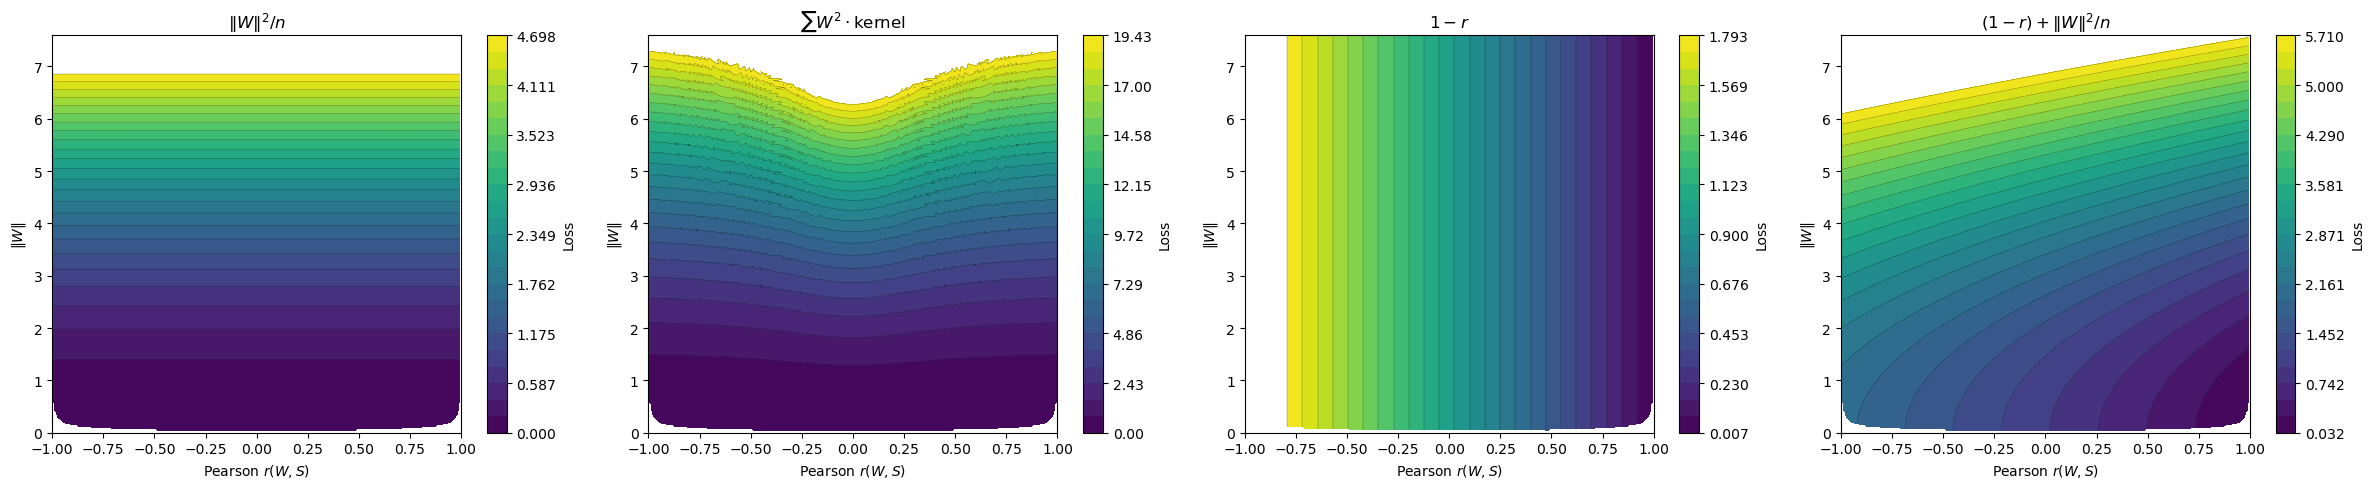

In [9]:
titles = {
    'Standard L2': r'$\|W\|^2 / n$',
    'L2 with kernel': r'$\sum W^2 \cdot \mathrm{kernel}$',
    'Correlation only': r'$1 - r$',
    'Correlation + L2': r'$(1 - r) + \|W\|^2 / n$',
}

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, name in zip(axes, loss_fns):
    data = Z_rm[name]
    levels = np.linspace(np.nanmin(data), np.nanpercentile(data, 90), 25)
    cs = ax.contourf(CG, MG, data, levels=levels, cmap='viridis')
    ax.contour(CG, MG, data, levels=levels, colors='k', linewidths=0.3, alpha=0.5)
    fig.colorbar(cs, ax=ax, label='Loss')
    ax.set_xlabel(r'Pearson $r(W, S)$')
    ax.set_ylabel(r'$\|W\|$')
    ax.set_title(titles[name])

plt.tight_layout()
plt.show()

## 3D surface plots

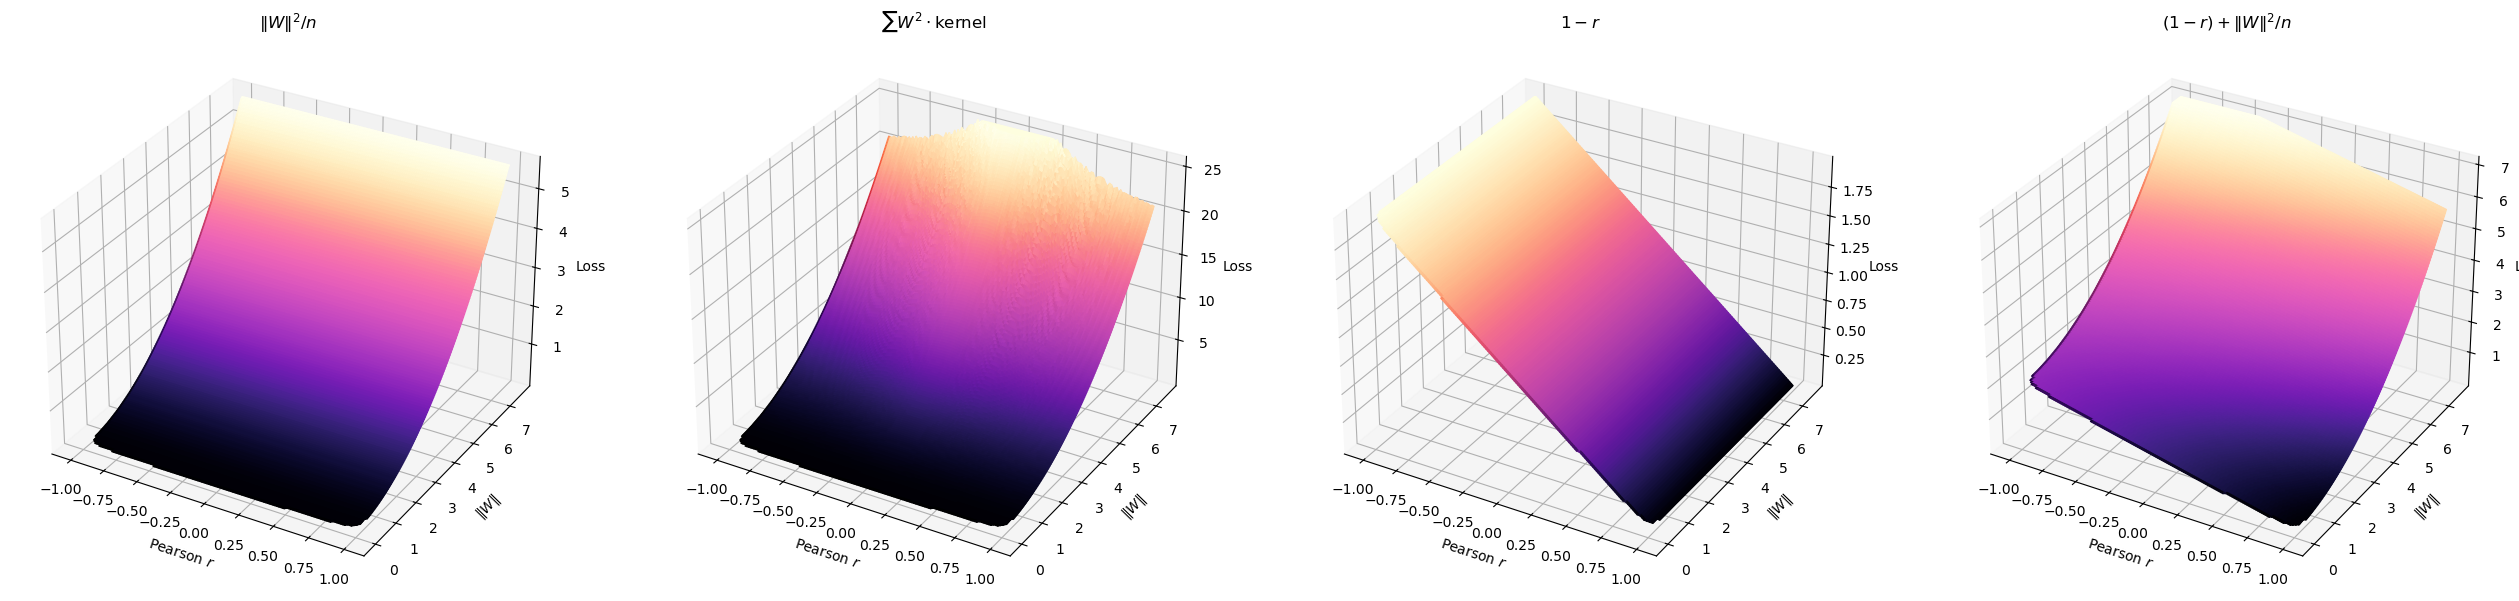

In [50]:
from matplotlib.colors import LightSource

ls = LightSource(azdeg=315, altdeg=45)
cmap = cm.magma

fig, axes = plt.subplots(1, 4, figsize=(26, 6), subplot_kw={'projection': '3d'})

stride = 2

for ax, name in zip(axes, loss_fns):
    data = Z_rm[name].copy()
    clip_max = np.nanpercentile(data, 99)
    data = np.where(np.isnan(data), np.nan, np.clip(data, None, clip_max))

    # Downsample
    data_ds = data[::stride, ::stride]
    cg_ds = CG[::stride, ::stride]
    mg_ds = MG[::stride, ::stride]

    # Shade only valid regions; NaN faces get clip_max color (won't be visible)
    shade_input = np.nan_to_num(data_ds, nan=float(clip_max))
    colors = ls.shade(shade_input, cmap=cmap, blend_mode='soft')

    # Make NaN face colors fully transparent
    nan_mask = np.isnan(data_ds)
    colors[nan_mask] = [0, 0, 0, 0]

    # Keep Z as NaN so plot_surface skips those faces
    ax.plot_surface(cg_ds, mg_ds, data_ds, facecolors=colors,
                    rstride=1, cstride=1, antialiased=True, shade=False)
    ax.set_xlabel(r'Pearson $r$')
    ax.set_ylabel(r'$\|W\|$')
    ax.set_zlabel('Loss')
    ax.set_title(titles[name])
    ax.view_init(elev=30, azim=-60)

fig.subplots_adjust()

plt.tight_layout()
plt.show()